## Imports and plot settings

In [111]:
# import packages
from collections import Counter
from pathlib import Path
import matplotlib.colors as mc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import re

# define path
path = Path.cwd()

# import files
modules = {'NUS': path / 'all_nus_modules_embedded.parquet',
         'SMU': path / 'all_smu_modules_embedded.parquet',
         'SUTD': path / 'all_sutd_modules_embedded.parquet'}
jobs = pd.read_parquet(path / 'processed_jobs_dual_embeddings.parquet', columns=['skills'])

##### SCHOOL COLOURS FOR VISUALISATIONS #####
# defining school colours
colours = {'All schools': '#4C8DCB', 'NUS': '#C77424', 'SMU': '#866B46', 'SUTD': '#A01735'}
# helper function: creates lighter version of a colour
light = lambda c, a=0.6: mc.to_hex(np.array(mc.to_rgb(c)) + (1 - np.array(mc.to_rgb(c))) * a)
# defining the output layout
layout = [('All schools', 'Deduplicated'), ('All schools', 'Not deduplicated'),('NUS', 'Deduplicated'), ('NUS', 'Not deduplicated'),
    ('SMU', 'Deduplicated'), ('SMU', 'Not deduplicated'),('SUTD', 'Deduplicated'), ('SUTD', 'Not deduplicated')]

## Job-demanded skills and university supplied skills extraction

In [55]:
##### SENTENCE EMBEDDING MODEL #####
# helper function: searches the model in your local cache, else uses the online model name.
def resolve_model_path():
    snapshots = Path.home() / '.cache' / 'huggingface' / 'hub' / 'models--sentence-transformers--all-mpnet-base-v2' / 'snapshots'
    if snapshots.exists():
        cached = sorted(p for p in snapshots.iterdir() if p.is_dir())
        if cached:
            return str(cached[-1])
    return 'sentence-transformers/all-mpnet-base-v2'
# defining the sentence embedding model
model = SentenceTransformer(resolve_model_path())
# defining batch size for cosine similarity calculation
BATCH = 256

##### SKILLS DEMANDED #####
# helper function: cleans and standardizes natural language text by lowercasing and removing extra spaces
clean = lambda s: ' '.join(str(s).lower().split()).strip()
# extracting skills demanded by the job market
demand = Counter(clean(skill) for skills in jobs['skills'].dropna() for skill in skills if clean(skill))
# defining total unique skills demand and population skills demand
total_skills_demanded = {'Deduplicated': len(demand), 'Not deduplicated': sum(demand.values())}
# helper alias used by later visualisation cells
totals = total_skills_demanded

# sorted list of unique skill names
skill_names = sorted(demand)
# helper function: normalizes embeddings into unit length
norm = lambda x: np.asarray(x, dtype=np.float32) / np.where(np.linalg.norm(x, axis=1, keepdims=True) == 0, 1, np.linalg.norm(x, axis=1, keepdims=True))
# converts skill_names into embeddings and normalises them
skill_vecs = norm(model.encode(skill_names, batch_size=128, show_progress_bar=False))

##### SKILLS SUPPLIED #####
# extract skills supplied by schools
supply = {k: np.vstack(pd.read_parquet(v, columns=['skill_embedding'], engine='fastparquet')['skill_embedding']).astype(np.float32) for k, v in modules.items()}
# union of the skill supplied by all three schools
supply['All schools'] = np.vstack([supply['NUS'], supply['SMU'], supply['SUTD']])

## Calculating skill coverage
`sentence-transformers/all-mpnet-base-v2` is used to convert both job-demanded skills and school-supplied skills into embeddings. Skill coverage is then measured by comparing these embeddings using cosine similarity. A job skill is considered covered if it has at least one matching school-supplied skill with cosine similarity above 0.55.

In [56]:
# helper function: calculcates skill coverage where covered = cosine similarity >= 0.55
def coverage(vecs):
    hits, vt = {}, norm(vecs).T
    for i in range(0, len(skill_names), BATCH):
        counts = (skill_vecs[i:i + BATCH] @ vt >= 0.55).sum(axis=1)
        hits.update({s: int(c) for s, c in zip(skill_names[i:i + BATCH], counts) if c})
    return {'Deduplicated': len(hits), 'Not deduplicated': sum(min(hits[s], demand[s]) for s in hits)}
# skill coverage for nus, smu, sutd, and all schools
coverage_results = {school: coverage(vecs) for school, vecs in supply.items()}
# show results for skill coverage calculation
pd.DataFrame([{'School': school, 'Metric': metric, 'Covered': coverage_results[school][metric], 'Total': totals[metric], 'Coverage %': round(coverage_results[school][metric] / totals[metric] * 100, 1)} for school, metric in layout])

,School,Metric,Covered,Total,Coverage %
0,All schools,Deduplicated,4775,9488,50.3
1,All schools,Not deduplicated,28426,334729,8.5
2,NUS,Deduplicated,4532,9488,47.8
3,NUS,Not deduplicated,24765,334729,7.4
4,SMU,Deduplicated,2644,9488,27.9
5,SMU,Not deduplicated,8928,334729,2.7
6,SUTD,Deduplicated,734,9488,7.7
7,SUTD,Not deduplicated,1176,334729,0.4


## Visualisation 1: Pie charts showing skill coverage
Each pie chart represents the full set of skills demanded in job postings, and shows the proportion of those skills that are also covered by university modules.

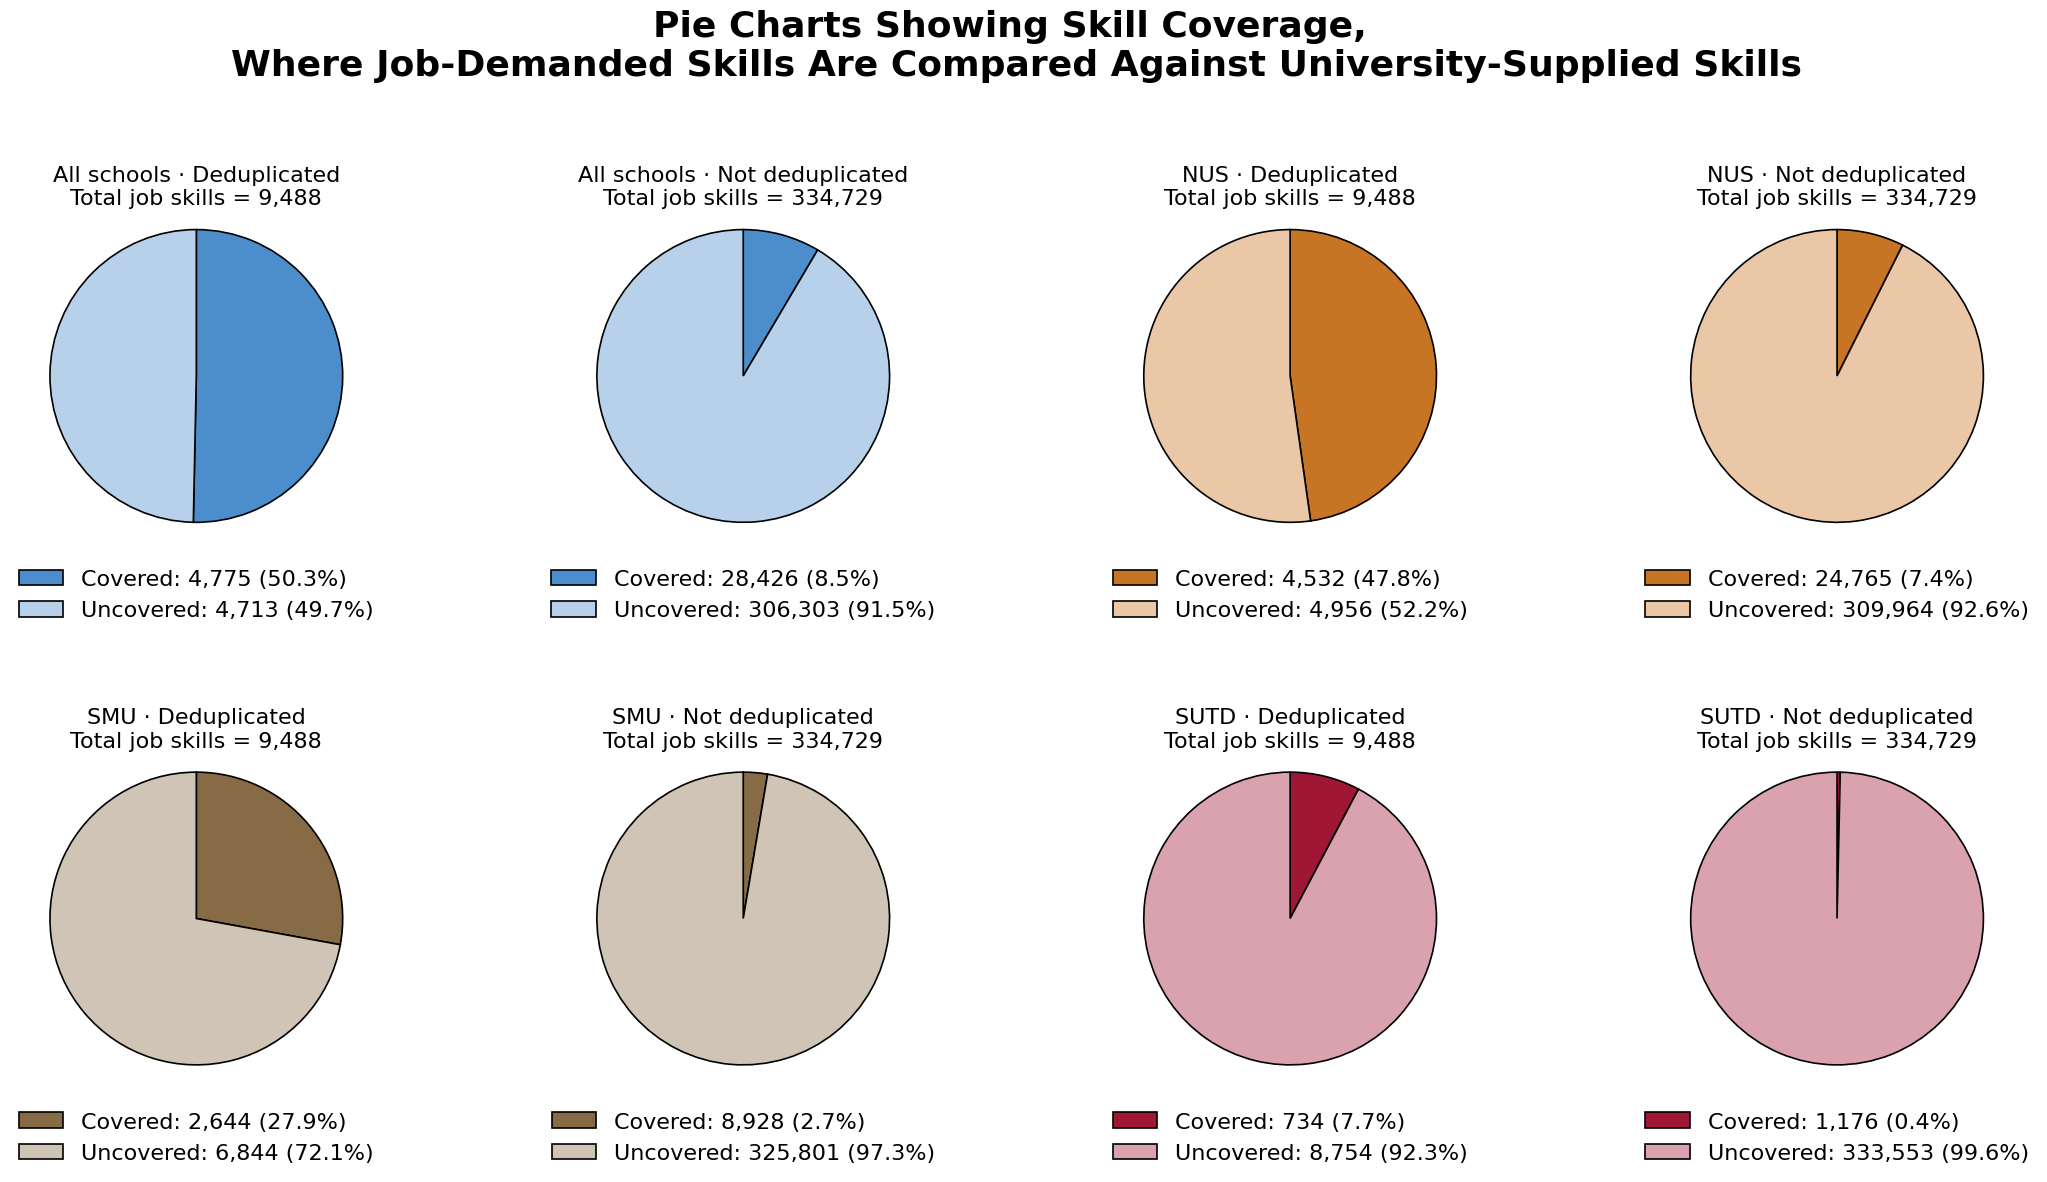

In [57]:
# defining the output layout
layout = [('All schools', 'Deduplicated'), ('All schools', 'Not deduplicated'),('NUS', 'Deduplicated'), ('NUS', 'Not deduplicated'),
    ('SMU', 'Deduplicated'), ('SMU', 'Not deduplicated'),('SUTD', 'Deduplicated'), ('SUTD', 'Not deduplicated')]
# defining plot size
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
# adding title
fig.suptitle('Pie Charts Showing Skill Coverage, \nWhere Job-Demanded Skills Are Compared Against University-Supplied Skills', 
             fontsize=26, fontweight='bold', y=1.05)
# plot pie charts
for ax, (school, metric) in zip(axes.flat, layout):
    total, covered = totals[metric], coverage_results[school][metric]
    vals = [covered, total - covered]
    labels = [f'Covered: {vals[0]:,} ({vals[0] / total:.1%})', f'Uncovered: {vals[1]:,} ({vals[1] / total:.1%})']
    wedges, _ = ax.pie(vals, radius=1.16, startangle=90, counterclock=False, colors=[colours[school], light(colours[school])], wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
    ax.set_title(f'{school} · {metric}\nTotal job skills = {total:,}', fontsize=16, pad=10)
    ax.legend(wedges, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=16)
    ax.set_aspect('equal')
# adjusts spacing
plt.subplots_adjust(left=0.03, right=0.97, top=0.86, bottom=0.08, wspace=0.28, hspace=0.72)
# save plot
plt.savefig('skill_coverage_pie_charts.png', dpi=300, bbox_inches='tight')
# show plot
plt.show()

### Determining the distribution of jobs across skill coverage percentages

1. **Extract unique skills covered by each school/all schools**  
   Extract all covered job-demanded skills for each school and deduplicate.

2. **Extract unique skills demanded by each job**  
   For every job, extract and clean the listed skills. Then, deduplicate.

3. **Compute deduplicated skill coverage for each job**  
   For each job, calculate the percentage of unique skills covered by each school/all schools:
    $$
    \text{Job-level coverage} = \frac{\text{Number of unique job skills covered}}{\text{Total number of unique job skills required by the job}} \times 100
    $$

In [58]:
# helper function: extracts the set of covered job-demanded skills for one school
def covered_skill_set(vecs):
    hits, vt = set(), norm(vecs).T
    for i in range(0, len(skill_names), BATCH):
        scores = (skill_vecs[i:i + BATCH] @ vt >= 0.55).any(axis=1)
        hits.update(skill for skill, covered in zip(skill_names[i:i + BATCH], scores) if covered)
    return hits
# helper function: computes deduplicated job-level coverage percentages
def job_level_coverage(covered_skills):
    values = []
    for skills in jobs['skills'].dropna():
        job_skills = {clean(skill) for skill in skills if clean(skill)}
        if not job_skills:
            values.append(0)
            continue
        values.append(len(job_skills & covered_skills) / len(job_skills) * 100)
    return np.array(values)
# define school order for histograms
school_order = ['All schools', 'NUS', 'SMU', 'SUTD']
# compute job-level coverage distributions
job_level_results = {school: job_level_coverage(covered_skill_set(supply[school])) for school in school_order}

## Visualisation 2: Histograms showing the distribution of jobs across deduplicated skill coverage
Each histogram shows how jobs are distributed by their deduplicated skill coverage.

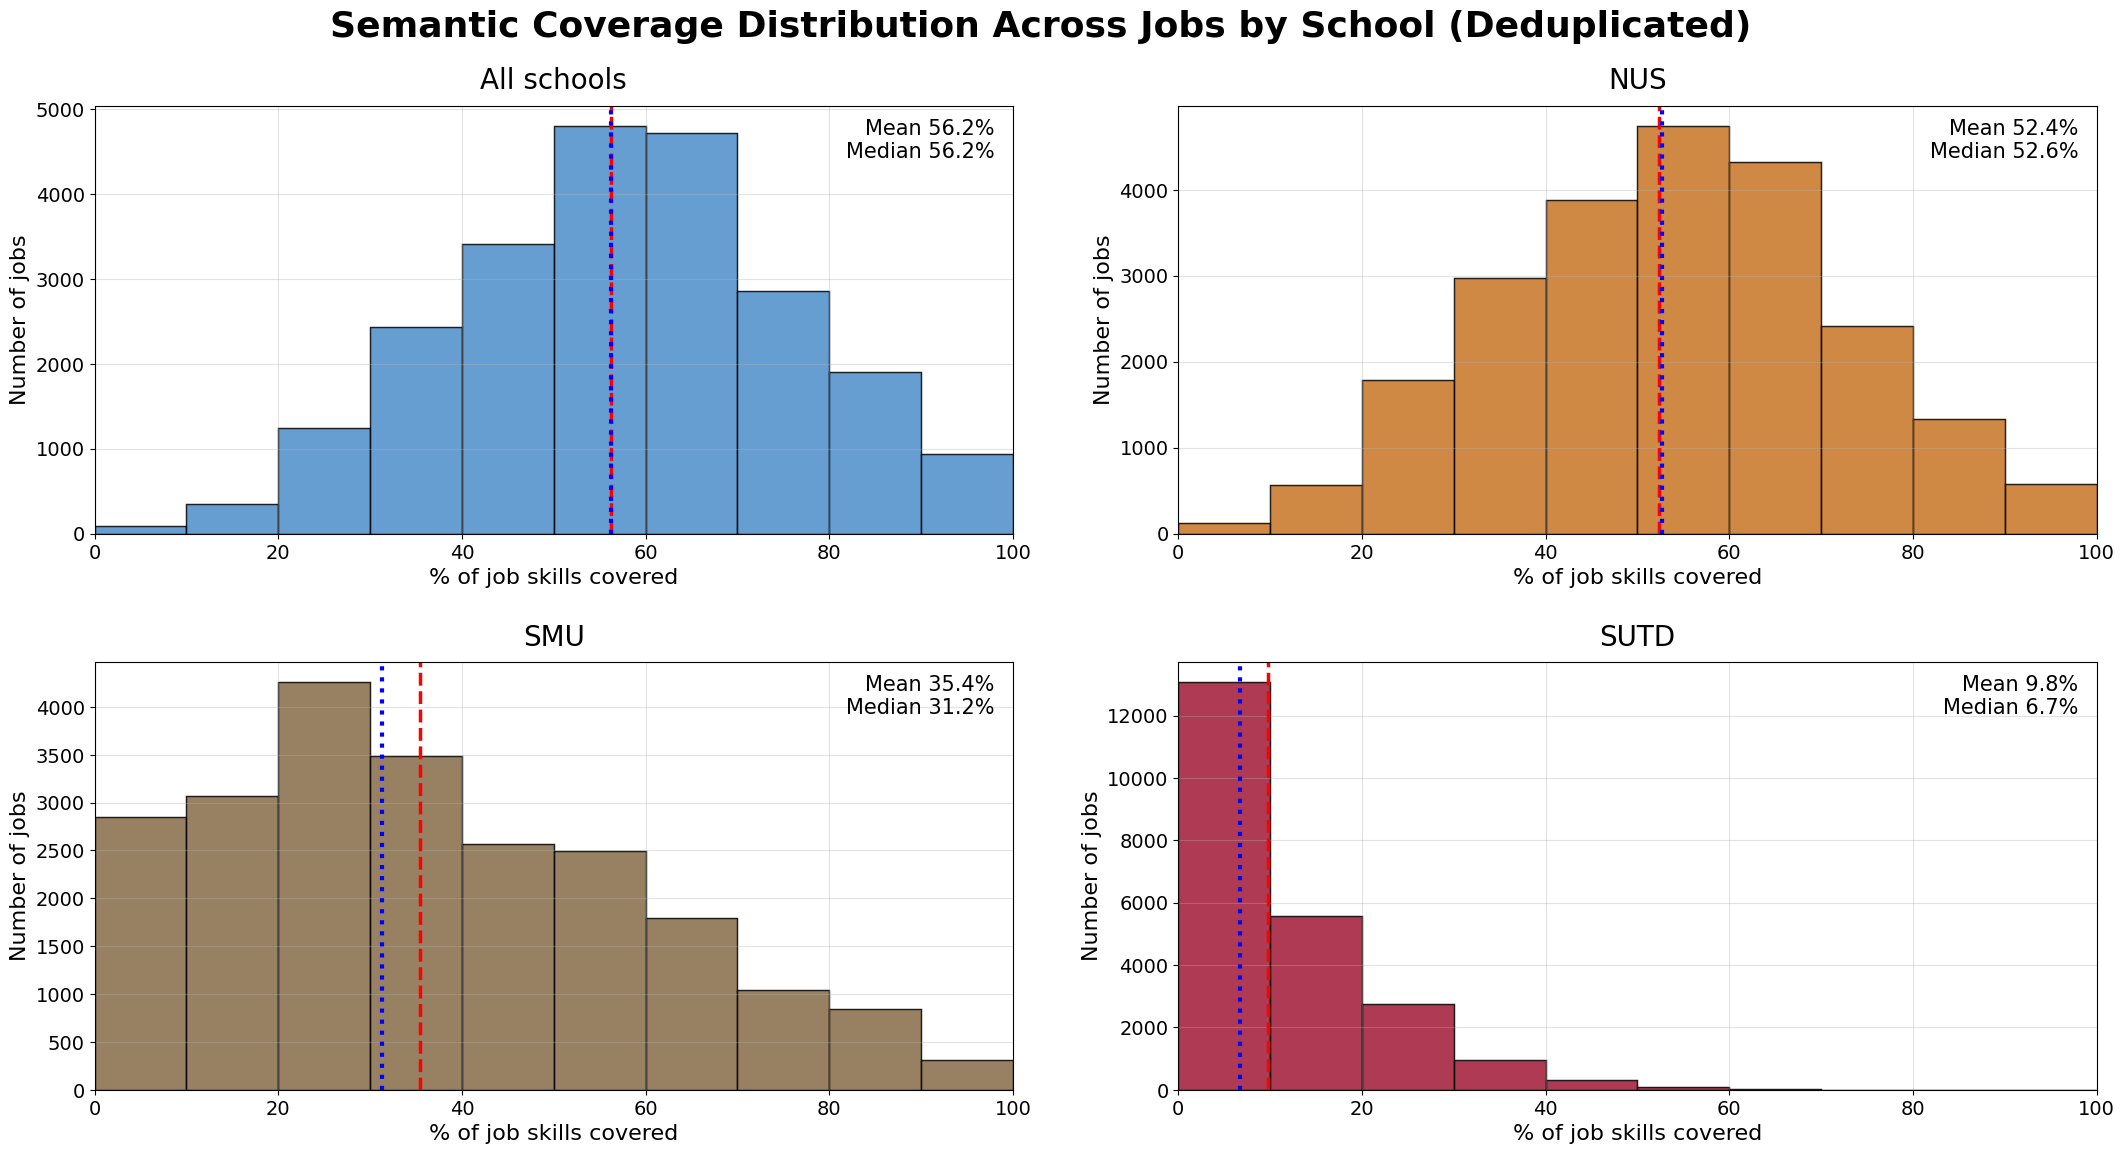

In [59]:
# defining plot size
fig, axes = plt.subplots(2, 2, figsize=(22, 12))
# adding title
fig.suptitle('Semantic Coverage Distribution Across Jobs by School (Deduplicated)', fontsize=26, fontweight='bold', y=0.98)
# plot histograms
for ax, school in zip(axes.flat, school_order):
    values = job_level_results[school]
    mean_value, median_value = values.mean(), np.median(values)
    ax.hist(values, bins=np.arange(0, 110, 10), color=colours[school], edgecolor='black', linewidth=1.05, alpha=0.85)
    ax.axvline(mean_value, color='red', linestyle='--', linewidth=2.5)
    ax.axvline(median_value, color='blue', linestyle=':', linewidth=3)
    ax.set_title(school, fontsize=20, pad=12)
    ax.set_xlabel('% of job skills covered', fontsize=16)
    ax.set_ylabel('Number of jobs', fontsize=16)
    ax.set_xlim(0, 100)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(alpha=0.35)
    ax.text(0.98, 0.97, f'Mean {mean_value:.1f}%\nMedian {median_value:.1f}%', transform=ax.transAxes,
            ha='right', va='top', fontsize=15)
# adjusts spacing
plt.subplots_adjust(left=0.07, right=0.98, top=0.90, bottom=0.08, wspace=0.18, hspace=0.30)
# save plot
plt.savefig('job_level_skill_coverage_distribution.png', dpi=300, bbox_inches='tight')
# show plot
plt.show()

## Calculating the demand-supply gap for each skill
The demand-supply gap for each skill is calculated as the difference between the number of jobs demanding the skill and the number of modules teaching the skill. Skills with the largest positive gaps are identified as those with the greatest unmet demand.

In [60]:
# helper function: computes the quantity supplied of each skill for each school/across all schools
def skill_supply_counts(vecs):
    counts_dict, vt = {}, norm(vecs).T
    for i in range(0, len(skill_names), BATCH):
        counts = (skill_vecs[i:i + BATCH] @ vt >= 0.55).sum(axis=1)
        counts_dict.update({skill: int(count) for skill, count in zip(skill_names[i:i + BATCH], counts)})
    return counts_dict

# for each skill, compute the quantity demanded by the job market, quantity supplied by all schools (in terms of number of modules teaching it, and the difference in the two
all_schools_supply_counts = skill_supply_counts(supply['All schools'])
semantic_demand_supply_df = pd.DataFrame([
    {
        'skill': skill,
        'job_demand': demand[skill],
        'all_schools_supply': all_schools_supply_counts.get(skill, 0),
    }
    for skill in skill_names
])
semantic_demand_supply_df['gap'] = semantic_demand_supply_df['job_demand'] - semantic_demand_supply_df['all_schools_supply']
semantic_demand_supply_df['job_demand_plus_one'] = semantic_demand_supply_df['job_demand'] + 1
semantic_demand_supply_df['all_schools_supply_plus_one'] = semantic_demand_supply_df['all_schools_supply'] + 1

# extract skills with the largest gaps
largest_uncovered_gaps_df = (semantic_demand_supply_df.sort_values(['gap', 'skill'], ascending=[False, True])
                             .head(12).reset_index(drop=True))

## Visualisation 3: demand-supply gap charts
1. The first scatter plot shows demand-supply gap across the full skill space. The skills with largest gaps are highlighted in red.
2. The second dumbbell plot functions as a zoom-in chart that shows the skills with the largest gaps and how large the gaps are.

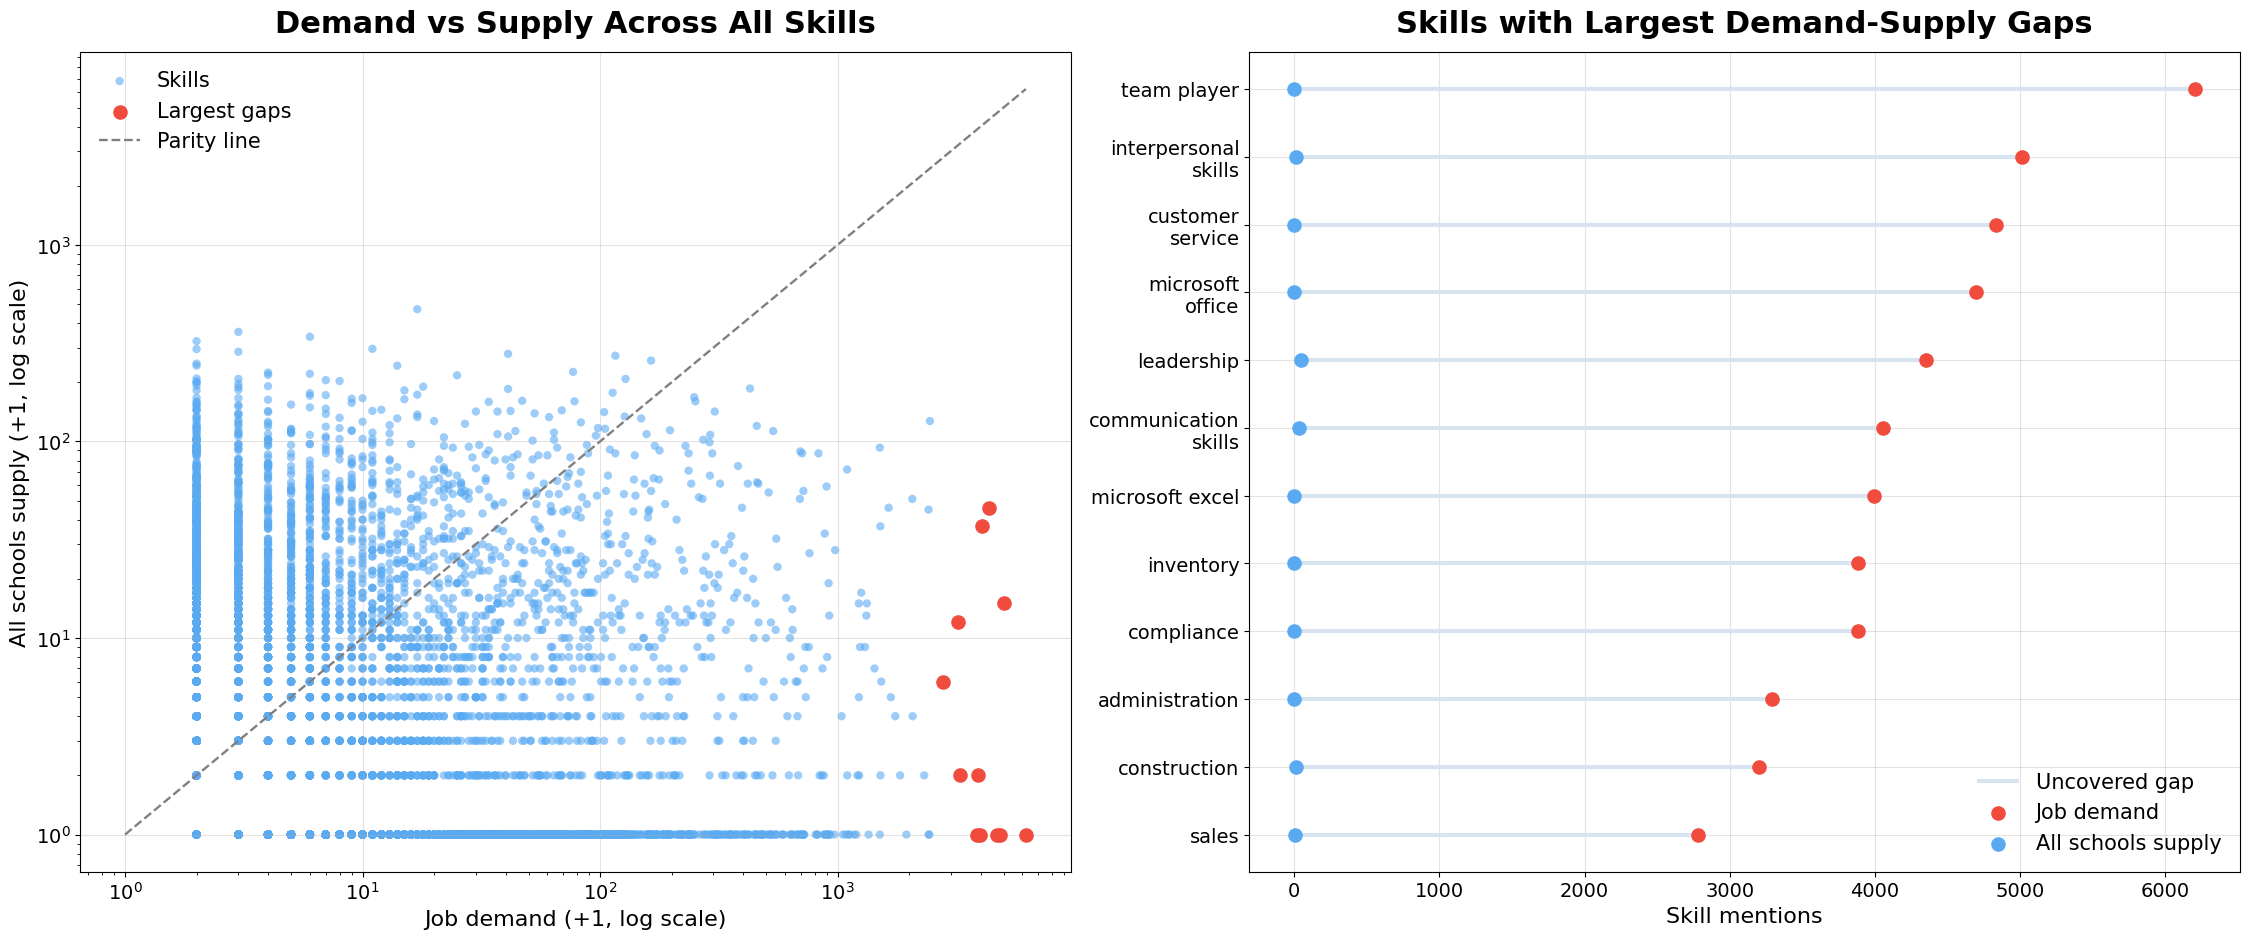

In [61]:
# defining plot size
fig, axes = plt.subplots(1, 2, figsize=(24, 10), gridspec_kw={'width_ratios': [1, 1]})

##### SCATTER PLOT #####
# add title
axes[0].set_title('Demand vs Supply Across All Skills', fontsize=22, fontweight='bold', pad=14)
# plot graph
axes[0].scatter(
    semantic_demand_supply_df['job_demand_plus_one'],
    semantic_demand_supply_df['all_schools_supply_plus_one'],
    s=36,
    color='#5AAAF2',
    alpha=0.6,
    edgecolors='none',
    label='Skills'
)
axes[0].scatter(
    largest_uncovered_gaps_df['job_demand_plus_one'],
    largest_uncovered_gaps_df['all_schools_supply_plus_one'],
    s=90,
    color='#F04B3D',
    label='Largest gaps',
    zorder=3
)
parity_max = max(
    semantic_demand_supply_df['job_demand_plus_one'].max(),
    semantic_demand_supply_df['all_schools_supply_plus_one'].max()
)
axes[0].plot([1, parity_max], [1, parity_max], linestyle='--', color='gray', linewidth=1.7, label='Parity line')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Job demand (+1, log scale)', fontsize=16)
axes[0].set_ylabel('All schools supply (+1, log scale)', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].grid(alpha=0.35)
axes[0].legend(frameon=False, fontsize=15, loc='upper left')

##### DUMBBELL PLOT #####
# add title
axes[1].set_title('Skills with Largest Demand-Supply Gaps', fontsize=22, fontweight='bold', pad=14)
# plot graph
plot_gaps_df = largest_uncovered_gaps_df.sort_values(['gap', 'skill'], ascending=[False, True]).copy()
plot_gaps_df['skill_label'] = plot_gaps_df['skill'].map(lambda skill: skill if len(skill) <= 15 or len(skill.split()) == 1 else '\n'.join([' '.join(skill.split()[:(len(skill.split()) + 1) // 2]), ' '.join(skill.split()[(len(skill.split()) + 1) // 2:])]))
axes[1].hlines(
    y=plot_gaps_df['skill_label'],
    xmin=plot_gaps_df['all_schools_supply'],
    xmax=plot_gaps_df['job_demand'],
    color='#D7E3EF',
    linewidth=3,
    label='Uncovered gap'
)
axes[1].scatter(
    plot_gaps_df['job_demand'],
    plot_gaps_df['skill_label'],
    color='#F04B3D',
    s=90,
    label='Job demand',
    zorder=3
)
axes[1].scatter(
    plot_gaps_df['all_schools_supply'],
    plot_gaps_df['skill_label'],
    color='#5AAAF2',
    s=90,
    label='All schools supply',
    zorder=3
)
axes[1].invert_yaxis()
axes[1].set_xlabel('Skill mentions', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)
axes[1].grid(alpha=0.35)
axes[1].legend(frameon=False, fontsize=15, loc='lower right')

# adjusts spacing
plt.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.08, wspace=0.18)
# save plot
plt.savefig('semantic_demand_supply_gap_charts.png', dpi=300, bbox_inches='tight')
# show plot
plt.show()

## Calculating skill coverage for most in-demand skills
1. **Extract the most in-demand skills**
Sort `semantic_demand_supply_df` by `job_demand` in descending order, break ties alphabetically by `skill`, and extract the top 12 skills for analysis.

2. **Compute the quantity supplied for each school/all schools**
For each school, use `skill_supply_counts(supply[school])` to calculate how many times each of the most in-demand skills is covered by a module.

3. **Express the quantity supplied for each school/all schools as a percentage of job market demand**


In [89]:
# extracting most in-demand skills
most_in_demand_skills_df = (
    semantic_demand_supply_df
    .sort_values(['job_demand', 'skill'], ascending=[False, True])
    .head(12)
    .reset_index(drop=True)
)
# defining set of schools
schools = ['All schools', 'NUS', 'SMU', 'SUTD']
# focusing on the most in-demand skills, compute the quantity supplied by each school/all schools
school_supply_counts = {
    school: skill_supply_counts(supply[school])
    for school in schools
}
# focusing on the most in-demand skills, express the quantity supplied by each school/all schools as a % of job market demand
for school in schools:
    most_in_demand_skills_df[f'{school}_share_pct'] = most_in_demand_skills_df.apply(
        lambda row: (
            school_supply_counts[school].get(row['skill'], 0) / row['job_demand'] * 100
            if row['job_demand'] else 0
        ),
        axis=1,
    )

## Visualisation 4: bar graph showing skill coverage for the top 12 most in-demand skills

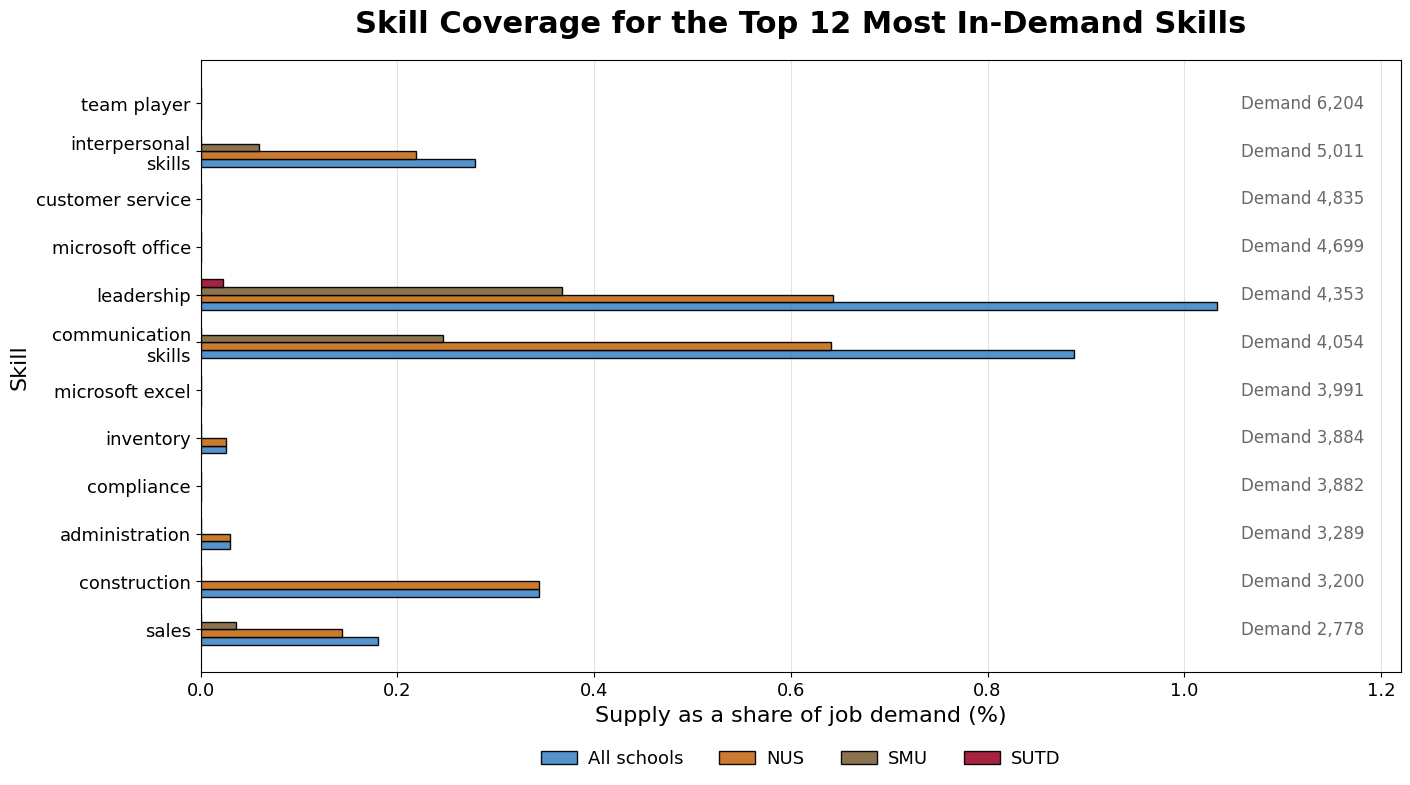

In [107]:
# helper function: create wrapped skill labels
def wrap_skill_label(skill):
    words = skill.split()
    if len(skill) <= 18 or len(words) == 1:
        return skill

    split_idx = (len(words) + 1) // 2
    return '\n'.join([
        ' '.join(words[:split_idx]),
        ' '.join(words[split_idx:])
    ])
most_in_demand_skills_df['skill_label'] = most_in_demand_skills_df['skill'].map(wrap_skill_label)
# load plot data
plot_df = most_in_demand_skills_df.iloc[::-1].reset_index(drop=True)
y = np.arange(len(plot_df))
# define plot settings
bar_height = 0.16
offsets = {'All schools': -0.24, 'NUS': -0.08, 'SMU': 0.08, 'SUTD': 0.24}
max_share = plot_df[[f'{school}_share_pct' for school in schools]].to_numpy().max()
# defining plot size
fig, ax = plt.subplots(figsize=(16, 8.5))
# plot bars
for school in schools:
    ax.barh(
        y + offsets[school],
        plot_df[f'{school}_share_pct'],
        height=bar_height,
        color=colours[school],
        edgecolor='black',
        alpha=0.95,
        label=school,
        zorder=3,
    )
# add title and axis formatting
ax.set_title(
    'Skill Coverage for the Top 12 Most In-Demand Skills',
    fontsize=22,
    fontweight='bold',
    pad=20
)
ax.set_yticks(y)
ax.set_yticklabels(plot_df['skill_label'])
ax.set_xlim(0, max_share * 1.18)
ax.set_xlabel('Supply as a share of job demand (%)', fontsize=16)
ax.set_ylabel('Skill', fontsize=16)
ax.tick_params(axis='both', labelsize=13)
ax.grid(axis='x', alpha=0.35, zorder=0)
# demand labels
for idx, row in plot_df.iterrows():
    ax.text(
        0.97,
        y[idx],
        f"Demand {row['job_demand']:,}",
        transform=ax.get_yaxis_transform(),
        ha='right',
        va='center',
        fontsize=12,
        color='dimgray'
    )
# add legend
ax.legend(
    frameon=False,
    ncol=4,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.10),
    fontsize=13,
    columnspacing=2.0,
    handletextpad=0.6
)
# adjust spacing
plt.tight_layout()
plt.subplots_adjust(left=0.22, right=0.97, top=0.90, bottom=0.18)
# save plot
plt.savefig('most_in_demand_skill_coverage_rates.png', dpi=300, bbox_inches='tight')
# show plot
plt.show()

## Robustness check 1: alternative embedding models
This robustness check ivolves the rerunning of the skill matching analysis using an alternative sentence embedding model, `all-MiniLM-L6-v2`, alongside the baseline model, `all-mpnet-base-v2`, to assess whether the main findings are robust to the choice of embedding model.


In [95]:
# helper function: searches a sentence transformer model in your local cache, else uses the online model name
def resolve_alt_model_path(model_name):
    snapshots = Path.home() / '.cache' / 'huggingface' / 'hub' / f"models--sentence-transformers--{model_name.replace('/', '--')}" / 'snapshots'
    if snapshots.exists():
        cached = sorted(p for p in snapshots.iterdir() if p.is_dir())
        if cached:
            return str(cached[-1])
    return model_name

# helper function: loads module text from module name, description and code
def load_module_texts(parquet_path):
    text_df = pd.read_parquet(parquet_path, columns=['module_name', 'description', 'module_code'], engine='fastparquet').fillna('')
    return [
        clean(' '.join(str(row[column]) for column in ['module_name', 'description', 'module_code'] if str(row[column]).strip()))
        for _, row in text_df.iterrows()
    ]

# helper function: calculates skill coverage for any set of skill vectors and module vectors
def coverage_from_vectors(skill_vectors, module_vectors, threshold=0.55):
    hits, covered, vt = {}, set(), norm(module_vectors).T
    for i in range(0, len(skill_names), BATCH):
        sims = skill_vectors[i:i + BATCH] @ vt
        counts = (sims >= threshold).sum(axis=1)
        hits.update({skill: int(count) for skill, count in zip(skill_names[i:i + BATCH], counts) if count})
        covered.update(skill for skill, matched in zip(skill_names[i:i + BATCH], counts > 0) if matched)
    return hits, covered

# helper function: computes the headline coverage metrics for one supply definition
def coverage_metrics_from_supply(supply_counts, covered_skills):
    job_level_values = job_level_coverage(covered_skills)
    return {
        'deduplicated_coverage_pct': len(covered_skills) / totals['Deduplicated'] * 100,
        'non_deduplicated_coverage_pct': sum(min(supply_counts[skill], demand[skill]) for skill in supply_counts) / totals['Not deduplicated'] * 100,
        'mean_job_level_deduplicated_coverage_pct': job_level_values.mean(),
        'median_job_level_deduplicated_coverage_pct': np.median(job_level_values),
    }

# defining robustness-check settings
model_specs = [
    ('Baseline model rerun (all-mpnet-base-v2)', 'all-mpnet-base-v2'),
    ('Alternative model (all-MiniLM-L6-v2)', 'all-MiniLM-L6-v2'),
]
bootstrap_iterations = 300
bootstrap_seed = 42
robustness_school_order = ['NUS', 'SMU', 'SUTD']

# load module text used for alternative embedding and lexical checks
school_module_texts = {school: load_module_texts(parquet_path) for school, parquet_path in modules.items()}
all_school_module_texts = [text for school in robustness_school_order for text in school_module_texts[school]]

# compare the baseline model and alternative models under the same text-encoding pipeline
embedding_model_rows = []
embedding_school_rows = []
for model_label, model_name in model_specs:
    alt_model = SentenceTransformer(resolve_alt_model_path(model_name))
    alt_skill_vecs = norm(alt_model.encode(skill_names, batch_size=128, show_progress_bar=False))
    alt_all_school_vecs = norm(alt_model.encode(all_school_module_texts, batch_size=64, show_progress_bar=False))
    alt_all_school_counts, alt_all_school_skills = coverage_from_vectors(alt_skill_vecs, alt_all_school_vecs)
    embedding_model_rows.append({
        'model': model_label,
        'system': 'All schools',
        **coverage_metrics_from_supply(alt_all_school_counts, alt_all_school_skills),
    })

    for school in robustness_school_order:
        alt_school_vecs = norm(alt_model.encode(school_module_texts[school], batch_size=64, show_progress_bar=False))
        alt_school_counts, alt_school_skills = coverage_from_vectors(alt_skill_vecs, alt_school_vecs)
        embedding_school_rows.append({
            'model': model_label,
            'school': school,
            **coverage_metrics_from_supply(alt_school_counts, alt_school_skills),
        })

# store the same-pipeline model comparison in tidy data frames
embedding_model_comparison_df = pd.DataFrame(embedding_model_rows).reset_index(drop=True)
embedding_school_comparison_df = pd.DataFrame(embedding_school_rows).sort_values(['model', 'school']).reset_index(drop=True)

## Results from robustness check 1

,model,system,deduplicated_coverage_pct,non_deduplicated_coverage_pct,mean_job_level_deduplicated_coverage_pct,median_job_level_deduplicated_coverage_pct
0,Baseline model rerun (all-mpnet-base-v2),All schools,52.824621,9.627788,59.803577,60.00
1,Alternative model (all-MiniLM-L6-v2),All schools,43.433811,5.894320,55.594564,56.25


,model,school_ranking_by_deduplicated_coverage
0,Alternative model (all-MiniLM-L6-v2),NUS > SMU > SUTD
1,Baseline model rerun (all-mpnet-base-v2),NUS > SMU > SUTD


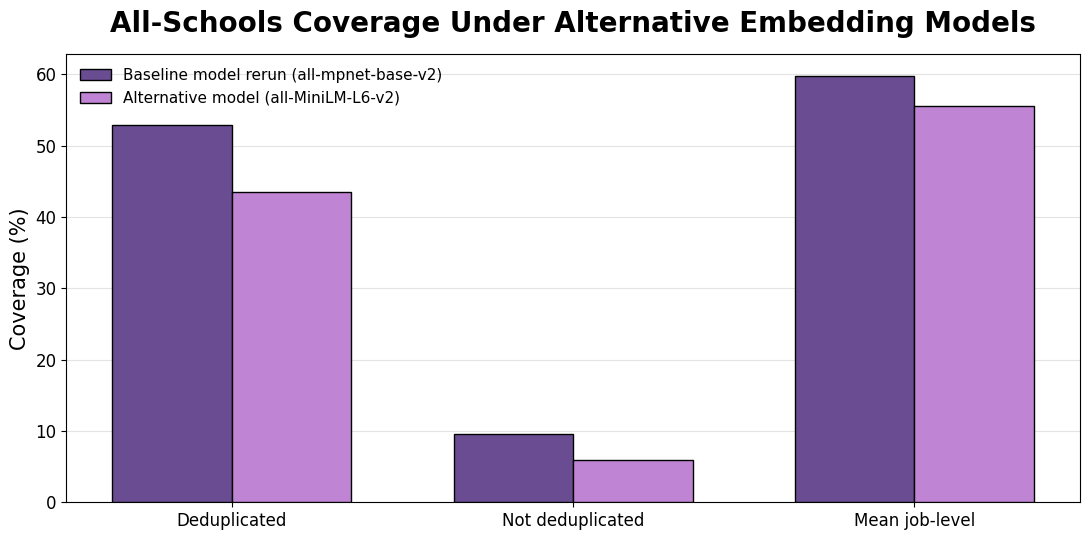

In [110]:
# display headline system-level comparison
display(embedding_model_comparison_df)

# display school ranking stability
display(embedding_ranking_stability_df)

# plot all-schools results across embedding models
fig, ax = plt.subplots(figsize=(11, 5.5))
for idx, (_, row) in enumerate(embedding_model_comparison_df.iterrows()):
    ax.bar(
        x + (idx - 0.5) * bar_width,
        [row[column] for column, _ in metric_specs],
        width=bar_width,
        color='#6A4C93' if idx == 0 else '#C084D4',
        label=row['model'],
        edgecolor = 'black',
        zorder=3,
    )
ax.set_title('All-Schools Coverage Under Alternative Embedding Models', fontsize=20, fontweight='bold', pad=16)
ax.set_ylabel('Coverage (%)', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels([label for _, label in metric_specs])
ax.tick_params(axis='both', labelsize=12)
ax.grid(axis='y', alpha=0.35, zorder=0)
ax.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

## Robustness check 2: threshold sensitivity
This cell tests whether the main findings remain broadly consistent when the similarity threshold is varied from 0.50 to 0.65, around the baseline threshold of 0.55.

In [100]:
# defining the thresholds
validation_thresholds = [0.50, 0.55, 0.60, 0.65]

# recompute all-schools and per-school coverage across a range of plausible thresholds
threshold_rows = []
school_threshold_rows = []

for threshold in validation_thresholds:
    all_school_counts, all_school_skills = coverage_from_vectors(skill_vecs, supply['All schools'], threshold)
    threshold_rows.append({
        'threshold': threshold,
        **coverage_metrics_from_supply(all_school_counts, all_school_skills),
    })

    for school in robustness_school_order:
        school_counts, school_skills = coverage_from_vectors(skill_vecs, supply[school], threshold)
        school_threshold_rows.append({
            'threshold': threshold,
            'school': school,
            **coverage_metrics_from_supply(school_counts, school_skills),
        })

# store results
threshold_robustness_df = pd.DataFrame(threshold_rows).sort_values('threshold').reset_index(drop=True)
school_threshold_robustness_df = pd.DataFrame(school_threshold_rows).sort_values(['threshold', 'school']).reset_index(drop=True)

## Results from robustness check 2

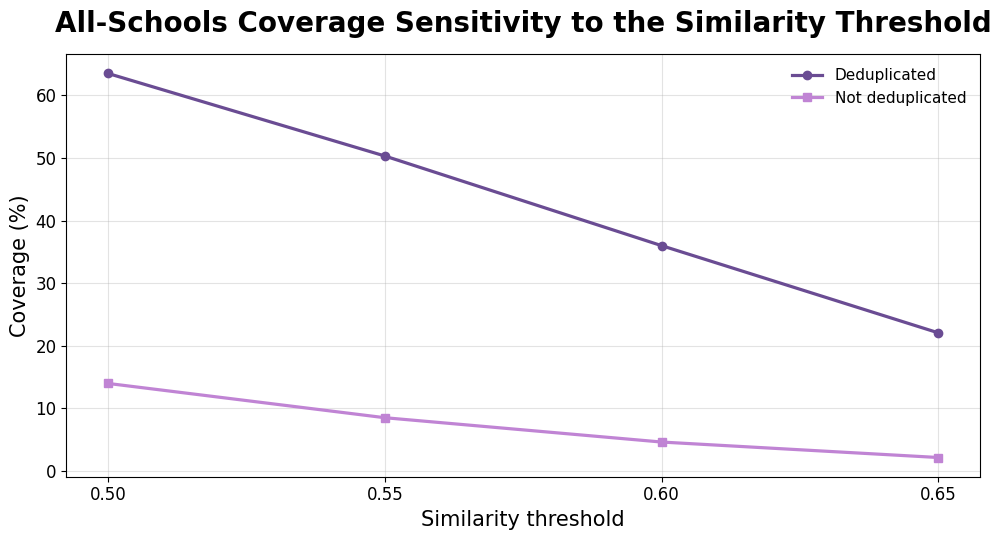

In [109]:
# plot all-schools sensitivity to the similarity threshold
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(
    threshold_robustness_df['threshold'],
    threshold_robustness_df['deduplicated_coverage_pct'],
    marker='o',
    linewidth=2.3,
    color='#6A4C93',
    label='Deduplicated',
)
ax.plot(
    threshold_robustness_df['threshold'],
    threshold_robustness_df['non_deduplicated_coverage_pct'],
    marker='s',
    linewidth=2.3,
    color='#C084D4',
    label='Not deduplicated',
)
ax.set_title('All-Schools Coverage Sensitivity to the Similarity Threshold', fontsize=20, fontweight='bold', pad=16)
ax.set_xlabel('Similarity threshold', fontsize=15)
ax.set_ylabel('Coverage (%)', fontsize=15)
ax.set_xticks(validation_thresholds)
ax.tick_params(axis='both', labelsize=12)
ax.grid(alpha=0.35)
ax.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

## Robustness check 3: bootstrap uncertainty
Bootstrap resampling assesses whether the estimated coverage rates remain stable when the jobs dataset is repeatedly resampled with replacement.

In [103]:
# helper function: computes deduplicated job-level coverage for any job subset
def job_level_coverage_for_frame(frame, covered_skills):
    values = []
    for skills in frame['skills'].dropna():
        job_skills = {clean(skill) for skill in skills if clean(skill)}
        if not job_skills:
            values.append(0)
            continue
        values.append(len(job_skills & covered_skills) / len(job_skills) * 100)
    return np.array(values)
# helper function: computes the headline coverage metrics for any job subset
def subset_metrics(frame, supply_counts, covered_skills):
    subset_demand = Counter(
        clean(skill)
        for skills in frame['skills'].dropna()
        for skill in skills
        if clean(skill)
    )
    subset_job_level_values = job_level_coverage_for_frame(frame, covered_skills)

    return {
        'deduplicated_coverage_pct': (
            len(set(subset_demand) & set(covered_skills)) / len(subset_demand) * 100
            if subset_demand else 0
        ),
        'non_deduplicated_coverage_pct': (
            sum(min(supply_counts.get(skill, 0), subset_demand[skill]) for skill in subset_demand)
            / sum(subset_demand.values()) * 100
            if subset_demand else 0
        ),
        'mean_job_level_deduplicated_coverage_pct': subset_job_level_values.mean(),
        'median_job_level_deduplicated_coverage_pct': np.median(subset_job_level_values),
    }
# defining the baseline supply setup
bootstrap_systems = {
    school: (school_supply_counts[school], covered_skill_set(supply[school]))
    for school in schools
}
# computing the original coverage metrics before resampling
bootstrap_baseline_metrics = {
    school: subset_metrics(jobs, supply_counts, covered_skills)
    for school, (supply_counts, covered_skills) in bootstrap_systems.items()
}
# resample jobs with replacement to test how sensitive the estimates are to the observed sample
bootstrap_rng = np.random.default_rng(bootstrap_seed)
bootstrap_rows = []
job_count = len(jobs)
for iteration in range(bootstrap_iterations):
    sampled_indices = bootstrap_rng.integers(0, job_count, size=job_count)
    sampled_jobs = jobs.iloc[sampled_indices].reset_index(drop=True)

    for school, (supply_counts, covered_skills) in bootstrap_systems.items():
        metrics = subset_metrics(sampled_jobs, supply_counts, covered_skills)
        bootstrap_rows.append({
            'iteration': iteration + 1,
            'system': school,
            **metrics,
        })
# convert bootstrap results into a dataframe
bootstrap_distribution_df = pd.DataFrame(bootstrap_rows)
# summarise 95% confidence intervals for per-school deduplicated coverage
bootstrap_summary_rows = []
for school in robustness_school_order:
    sample_values = bootstrap_distribution_df.loc[
        bootstrap_distribution_df['system'] == school,
        'deduplicated_coverage_pct'
    ]

    bootstrap_summary_rows.append({
        'system': school,
        'point_estimate_pct': bootstrap_baseline_metrics[school]['deduplicated_coverage_pct'],
        'ci_lower_pct': sample_values.quantile(0.025),
        'ci_upper_pct': sample_values.quantile(0.975),
    })
# store results
school_bootstrap_plot_df = pd.DataFrame(bootstrap_summary_rows)

## Results from robustness check 3

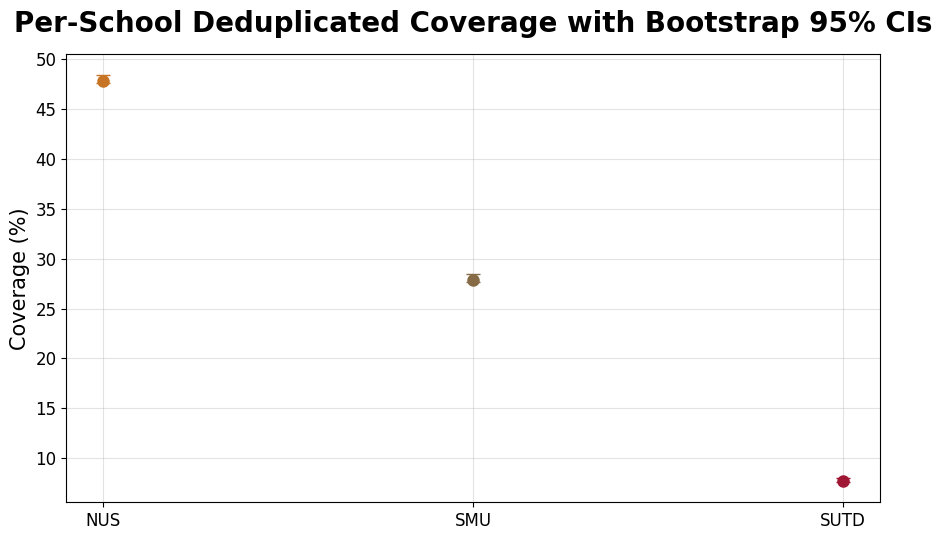

In [105]:
# plot 95% bootstrap confidence intervals for per-school deduplicated coverage
fig, ax = plt.subplots(figsize=(9, 5.5))
for _, row in school_bootstrap_plot_df.iterrows():
    ax.errorbar(
        row['system'],
        row['point_estimate_pct'],
        yerr=[
            [row['point_estimate_pct'] - row['ci_lower_pct']],
            [row['ci_upper_pct'] - row['point_estimate_pct']],
        ],
        fmt='o',
        color=colours[row['system']],
        markersize=8,
        capsize=5,
        linewidth=2,
    )

ax.set_title('Per-School Deduplicated Coverage with Bootstrap 95% CIs', fontsize=20, fontweight='bold', pad=16)
ax.set_ylabel('Coverage (%)', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()

## Validation: lexical baseline comparison
This cell checks whether semantic matching captures meaningful relationships beyond simple exact phrase overlap between job skills and module text.


In [106]:
# helper function: compiles an exact-phrase regex pattern for one skill
def compile_skill_phrase_pattern(skill):
    tokens = [token for token in clean(skill).split() if token]
    if not tokens:
        return None
    return re.compile(r'(?<!\w)' + r'\s+'.join(re.escape(token) for token in tokens) + r'(?!\w)')
# computing the lexical exact-phrase baseline across all school module text
lexical_baseline_counts = {}
lexical_covered_skills = set()
for skill in skill_names:
    pattern = compile_skill_phrase_pattern(skill)
    if pattern is None:
        continue
    match_count = sum(bool(pattern.search(text)) for text in all_school_module_texts)
    if match_count > 0:
        lexical_baseline_counts[skill] = int(match_count)
        lexical_covered_skills.add(skill)
# computing coverage metrics for the lexical baseline
lexical_baseline_metrics = coverage_metrics_from_supply(
    lexical_baseline_counts,
    lexical_covered_skills,
)
# storing the semantic-versus-lexical comparison in a tidy dataframe
lexical_baseline_comparison_df = pd.DataFrame([
    {
        'method': 'Semantic similarity',
        'deduplicated_coverage_pct': (
            coverage_results['All schools']['Deduplicated'] / totals['Deduplicated'] * 100
        ),
        'non_deduplicated_coverage_pct': (
            coverage_results['All schools']['Not deduplicated'] / totals['Not deduplicated'] * 100
        ),
        'mean_job_level_deduplicated_coverage_pct': job_level_results['All schools'].mean(),
    },
    {
        'method': 'Lexical exact phrase',
        **lexical_baseline_metrics,
    },
])

## Results from validation check

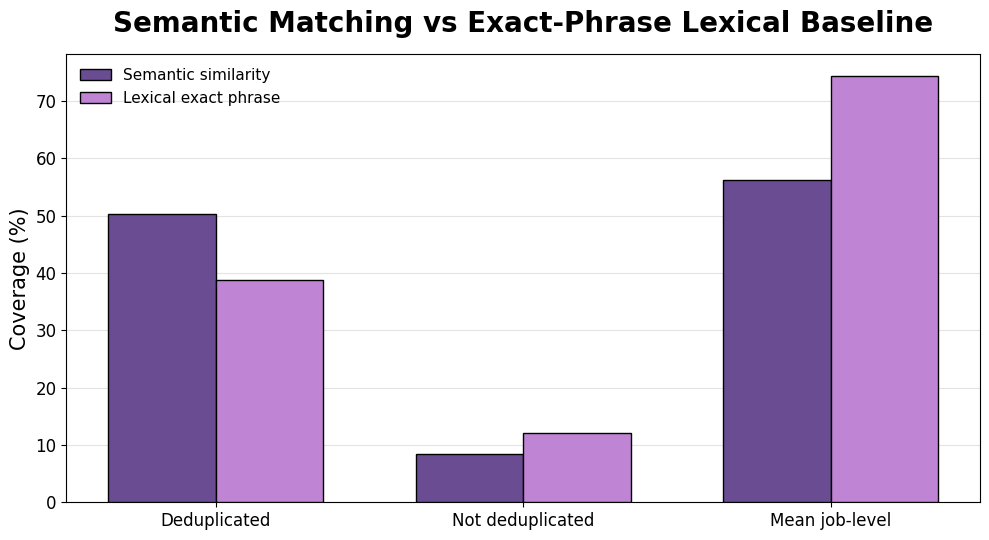

In [108]:
# creating the figure for the semantic-versus-lexical comparison plot
fig, ax = plt.subplots(figsize=(10, 5.5))
# defining the coverage metrics included in the semantic-versus-lexical comparison
lexical_metric_specs = [
    ('deduplicated_coverage_pct', 'Deduplicated'),
    ('non_deduplicated_coverage_pct', 'Not deduplicated'),
    ('mean_job_level_deduplicated_coverage_pct', 'Mean job-level'),
]
# defining the x-axis positions for the grouped bars
x = np.arange(len(lexical_metric_specs))
# defining the bar width for the grouped comparison plot
bar_width = 0.35
# plotting coverage estimates for semantic matching and lexical exact-phrase matching
for idx, (_, row) in enumerate(lexical_baseline_comparison_df.iterrows()):
    ax.bar(
        x + (idx - 0.5) * bar_width,
        [row[column] for column, _ in lexical_metric_specs],
        width=bar_width,
        color='#6A4C93' if row['method'] == 'Semantic similarity' else '#C084D4',
        edgecolor = 'black',
        label=row['method'],
        zorder=3,
    )
ax.set_title('Semantic Matching vs Exact-Phrase Lexical Baseline', fontsize=20, fontweight='bold', pad=16)
ax.set_ylabel('Coverage (%)', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels([label for _, label in lexical_metric_specs])
ax.tick_params(axis='both', labelsize=12)
ax.grid(axis='y', alpha=0.35, zorder=0)
ax.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()